In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df2 = pd.read_csv(r'E:\Gen AI\AQI_Analysis\Dataset\station_day.csv')

In [3]:
df2.sample(5)

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
105784,WB009,2020-03-17,64.41,122.74,18.85,63.60,82.49,20.17,0.75,8.32,45.84,20.22,35.04,2.8,125.0,Moderate
40632,DL029,2020-04-18,29.00,78.50,2.19,12.56,8.48,42.51,0.43,NaN,76.26,1.69,2.48,NaN,NaN,NaN
93153,TN001,2018-03-20,56.85,NaN,6.94,8.81,8.82,NaN,1.15,7.12,23.27,0.55,0.94,NaN,90.0,Satisfactory
35288,DL025,2017-09-24,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,0.00,0.00,NaN,NaN,NaN
88891,TG005,2016-11-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   StationId   108035 non-null  object 
 1   Date        108035 non-null  object 
 2   PM2.5       86410 non-null   float64
 3   PM10        65329 non-null   float64
 4   NO          90929 non-null   float64
 5   NO2         91488 non-null   float64
 6   NOx         92535 non-null   float64
 7   NH3         59930 non-null   float64
 8   CO          95037 non-null   float64
 9   SO2         82831 non-null   float64
 10  O3          82467 non-null   float64
 11  Benzene     76580 non-null   float64
 12  Toluene     69333 non-null   float64
 13  Xylene      22898 non-null   float64
 14  AQI         87025 non-null   float64
 15  AQI_Bucket  87025 non-null   object 
dtypes: float64(13), object(3)
memory usage: 13.2+ MB


In [5]:
df2.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,86410.000000,65329.000000,90929.000000,91488.000000,92535.000000,59930.000000,95037.000000,82831.000000,82467.000000,76580.000000,69333.000000,22898.000000,87025.000000
mean,80.272571,157.968427,23.123424,35.240760,41.195055,28.732875,1.605749,12.257634,38.134836,3.358029,15.345394,2.423446,179.749290
std,76.526403,123.418672,34.491019,29.510827,45.145976,24.897797,4.369578,12.984723,39.128004,11.156234,29.348587,6.472409,131.324339
min,0.020000,0.010000,0.010000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,8.000000
25%,31.880000,70.150000,4.840000,15.090000,13.970000,11.900000,0.530000,5.040000,18.895000,0.160000,0.690000,0.000000,86.000000
50%,55.950000,122.090000,10.290000,27.210000,26.660000,23.590000,0.910000,8.950000,30.840000,1.210000,4.330000,0.400000,132.000000
75%,99.920000,208.670000,24.980000,46.930000,50.500000,38.137500,1.450000,14.920000,47.140000,3.610000,17.510000,2.110000,254.000000
max,1000.000000,1000.000000,470.000000,448.050000,467.630000,418.900000,175.810000,195.650000,963.000000,455.030000,454.850000,170.370000,2049.000000


### Observation
This dataset is much bigger than the city day file because it is at station level. It also has many missing values, so cleaning is important before comparing stations.


In [6]:
df2.isnull().sum()

StationId         0
Date              0
PM2.5         21625
PM10          42706
NO            17106
NO2           16547
NOx           15500
NH3           48105
CO            12998
SO2           25204
O3            25568
Benzene       31455
Toluene       38702
Xylene        85137
AQI           21010
AQI_Bucket    21010
dtype: int64

In [7]:
df2.isnull().mean()*100

StationId      0.000000
Date           0.000000
PM2.5         20.016661
PM10          39.529782
NO            15.833758
NO2           15.316333
NOx           14.347202
NH3           44.527237
CO            12.031286
SO2           23.329477
O3            23.666404
Benzene       29.115564
Toluene       35.823576
Xylene        78.805017
AQI           19.447401
AQI_Bucket    19.447401
dtype: float64

### Observation
`Xylene` has very high missing values, so dropping it is reasonable here. `NH3` and `PM10` also have a lot of missing data, so later results should be read carefully.


In [8]:
df2 = df2.drop('Xylene', axis=1)

In [9]:
df2 = df2.dropna(subset=df2.columns.difference(['StationId', 'Date']), how='all')

In [10]:
df2.isnull().mean()*100

StationId      0.000000
Date           0.000000
PM2.5         14.569883
PM10          35.411826
NO            10.102129
NO2            9.549468
NOx            8.514341
NH3           40.749602
CO             6.040713
SO2           18.108298
O3            18.468170
Benzene       24.288412
Toluene       31.453231
AQI           13.961857
AQI_Bucket    13.961857
dtype: float64

### Observation
After dropping `Xylene` and removing rows that were almost empty, the dataset becomes easier to use. This keeps the useful station-day records and removes weak rows.


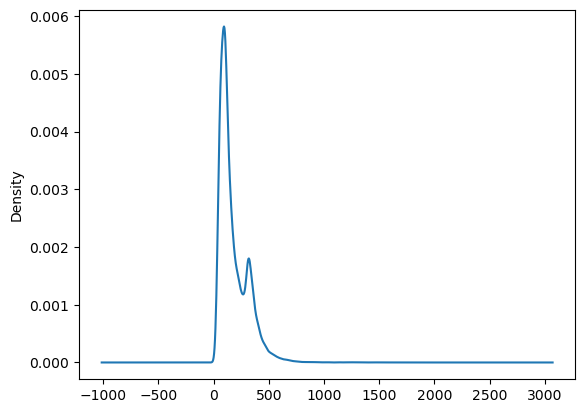

In [11]:
df2['AQI'].plot(kind='kde')
plt.show()

### Observation
This AQI curve is not balanced. Most values are in the lower or middle range, but some days have much higher AQI, so the data is skewed.


In [12]:
df2['AQI'].skew()

1.9300876873003958

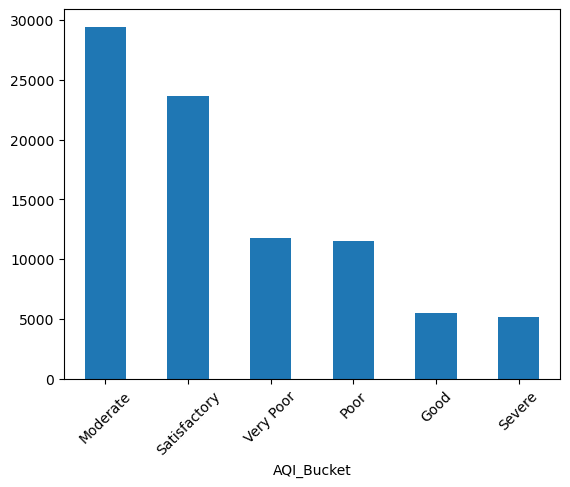

In [13]:
df2['AQI_Bucket'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

### Observation
This plot shows how often each AQI level appears. Some air quality groups are much more common than others, so the stations do not spend equal time in every category.


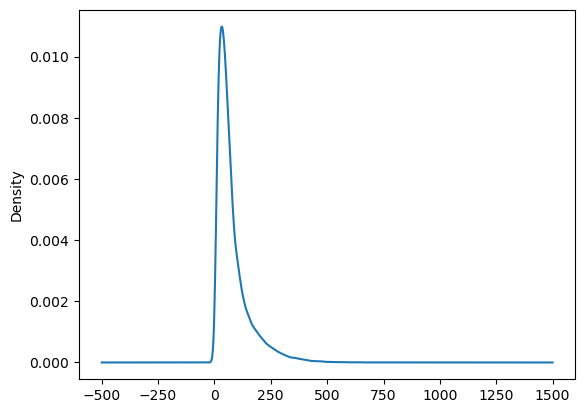

In [14]:
df2['PM2.5'].plot(kind='kde')
plt.show()

### Observation
PM2.5 is spread unevenly. Many days stay in a lower range, but some days go much higher.


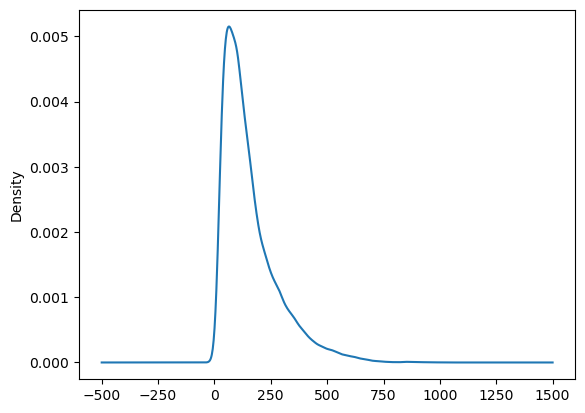

In [15]:
df2['PM10'].plot(kind='kde')
plt.show()

### Observation
PM10 also looks stretched to one side. That usually means some heavy pollution days are pulling the curve.


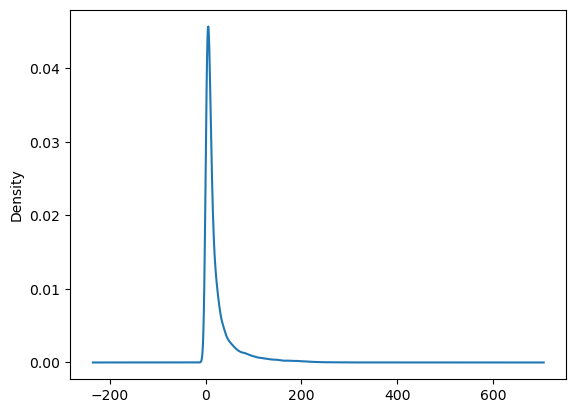

In [16]:
df2['NO'].plot(kind='kde')
plt.show()

### Observation
NO values are more concentrated in a smaller range, but there are still some higher readings.


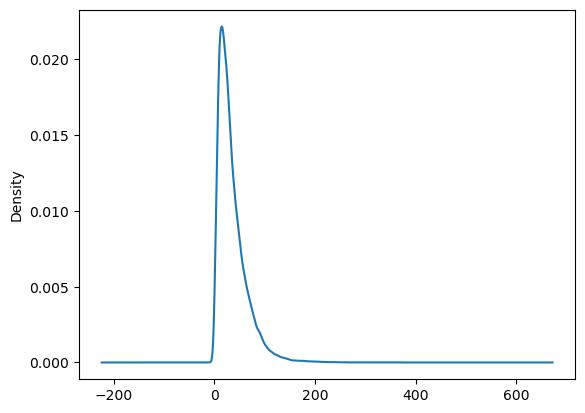

In [17]:
df2['NO2'].plot(kind='kde')
plt.show()

### Observation
NO2 is also unevenly spread. A smaller number of days have much higher values than the rest.


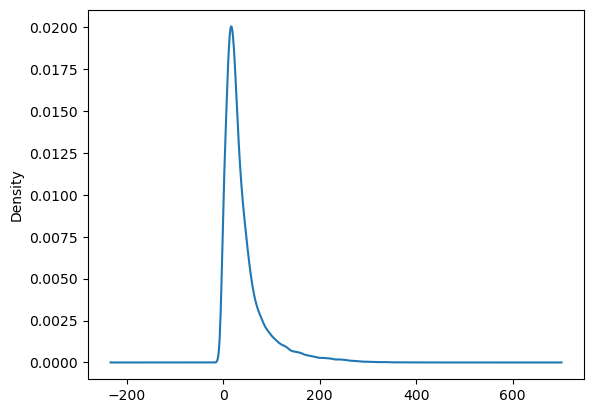

In [18]:
df2['NOx'].plot(kind='kde')
plt.show()

### Observation
NOx has a long tail too, which suggests some strong spikes in pollution.


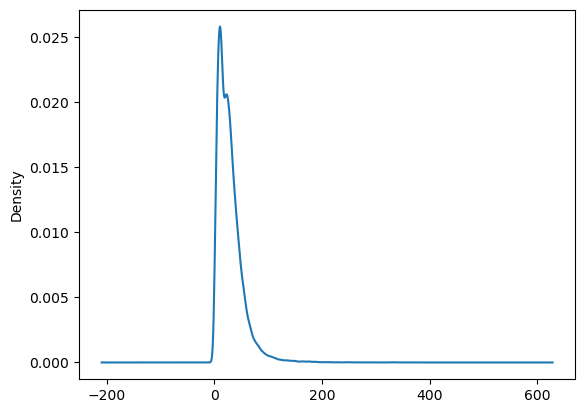

In [19]:
df2['NH3'].plot(kind='kde')
plt.show()

### Observation
NH3 is also skewed. Most values are lower, but some days show much higher readings.


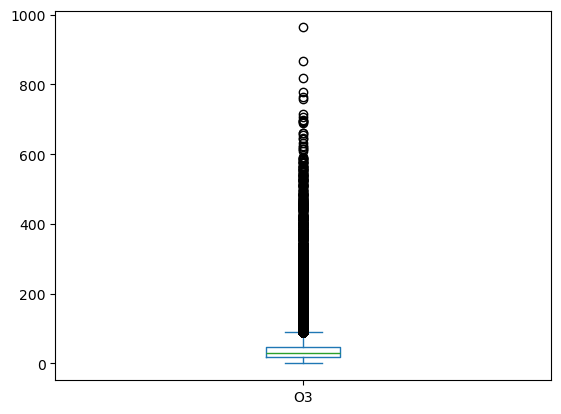

In [20]:
df2['O3'].plot(kind='box')
plt.show()

### Observation
The O3 box plot shows outliers. That means a few days had ozone levels very different from the normal range.


In [21]:
for col in df2.select_dtypes(include='number').columns.drop('AQI'):
    df2[col] = df2.groupby('StationId')[col].transform(lambda x: x.fillna(x.median()))

In [22]:
for col in df2.select_dtypes(include='number').columns.drop('AQI'):
    df2[col] = df2[col].fillna(df2[col].median())

In [23]:
df2.isnull().sum()

StationId         0
Date              0
PM2.5             0
PM10              0
NO                0
NO2               0
NOx               0
NH3               0
CO                0
SO2               0
O3                0
Benzene           0
Toluene           0
AQI           14122
AQI_Bucket    14122
dtype: int64

### Observation
Filling missing values by station median is better than using one value for every station. It keeps the station-level pattern more realistic, but the filled values are still estimates.


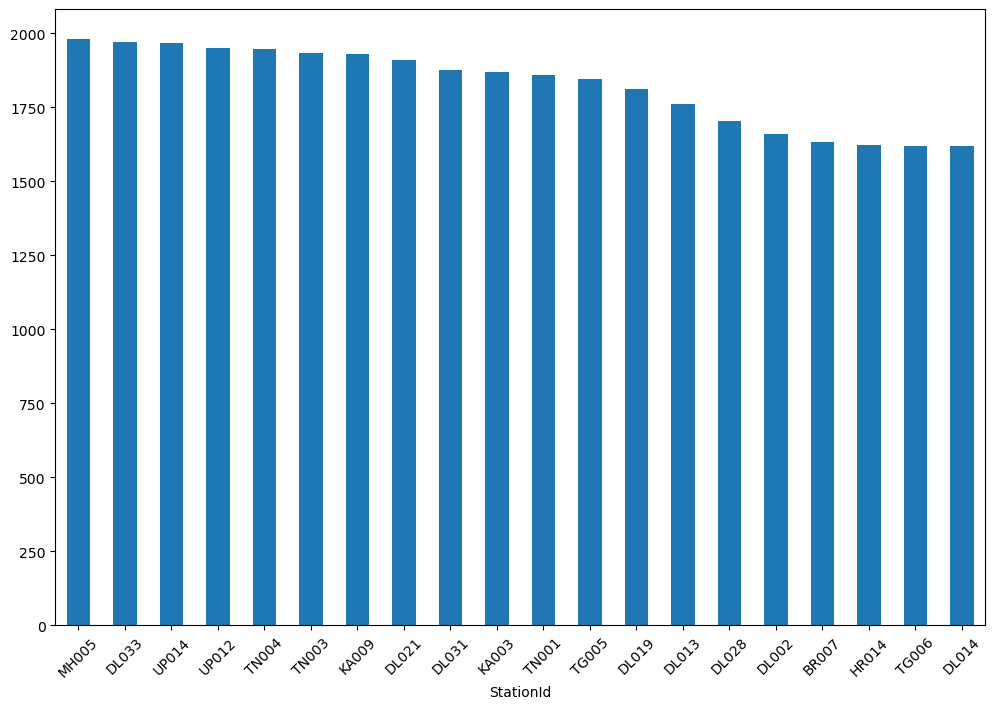

In [24]:
df2['StationId'].value_counts().head(20).plot(kind='bar', figsize=(12, 8))
plt.xticks(rotation=45)
plt.show()

### Observation
This plot shows some stations have many more records than others. So the dataset is not evenly spread across stations.


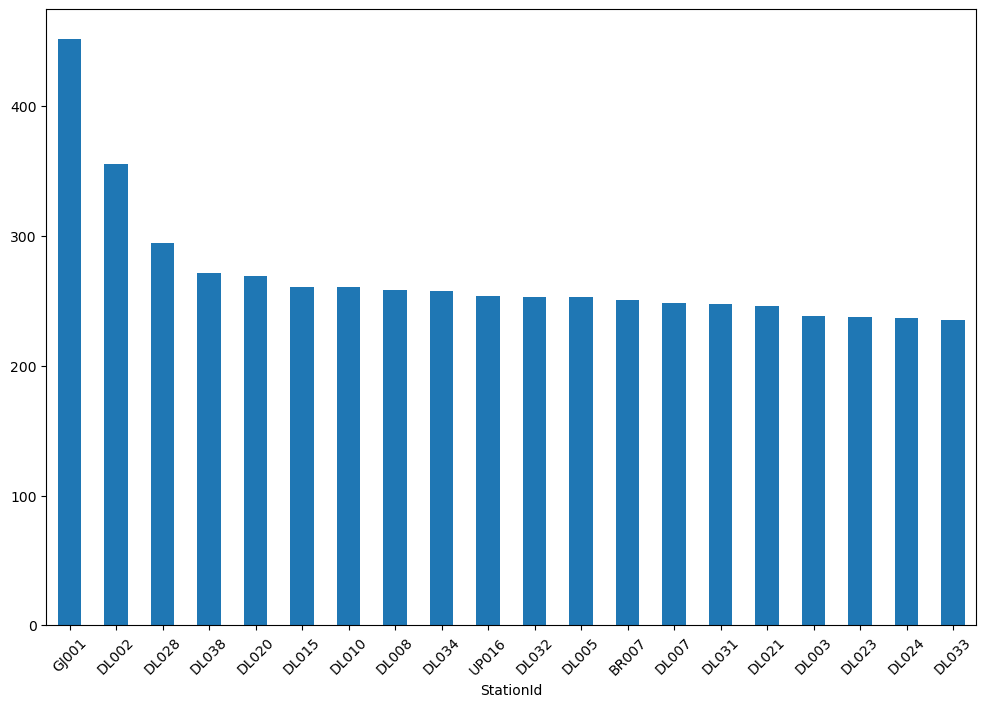

In [25]:
station_aqi = df2.groupby('StationId')['AQI'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
station_aqi.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

### Observation
Average AQI is not the same across stations. Some stations stay much more polluted than others.


In [26]:
df2[df2['AQI'] == df2['AQI'].max()]

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
52402,GJ001,2018-02-19,242.66,107.96,132.47,199.17,246.03,23.66,132.47,46.78,44.06,0.74,5.81,2049.0,Severe


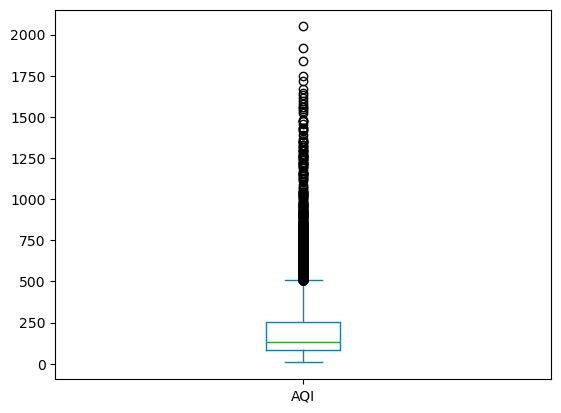

In [27]:
df2['AQI'].plot(kind='box')
plt.show()

### Observation
The AQI box plot shows outliers, so a few station-days had very bad air compared to the usual pattern.


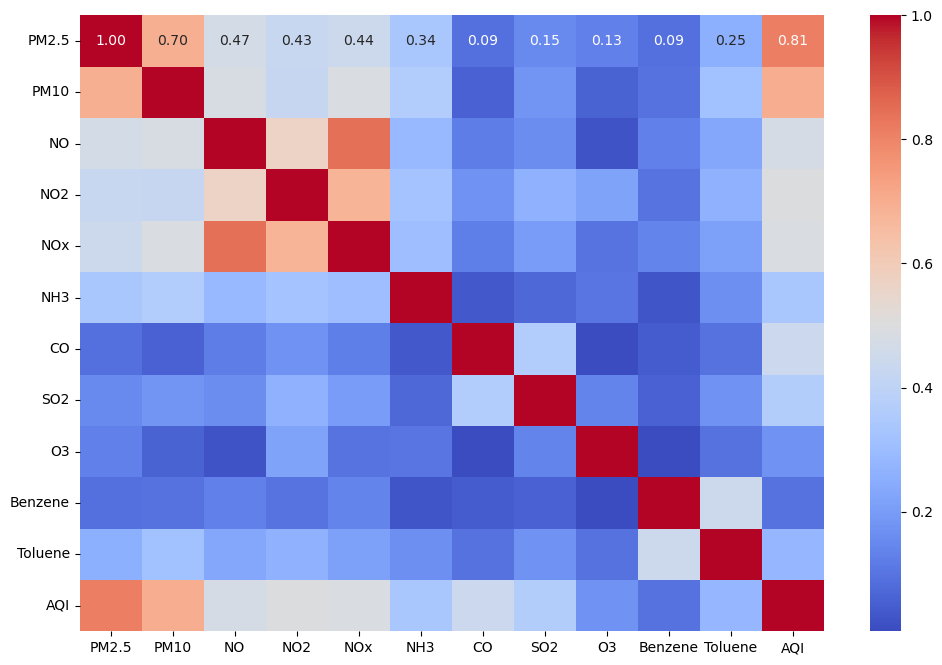

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(df2.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

### Observation
The heatmap shows which pollution measures move together. Stronger values mean a stronger relationship.


In [29]:
df2['Date'] = pd.to_datetime(df2['Date'])

In [30]:
season_map = {
    1: 'Winter', 2: 'Winter', 3: 'Summer',
    4: 'Summer', 5: 'Summer', 6: 'Summer',
    7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
    10: 'Monsoon', 11: 'Winter', 12: 'Winter'
}

df2['Season'] = df2['Date'].dt.month.map(season_map)

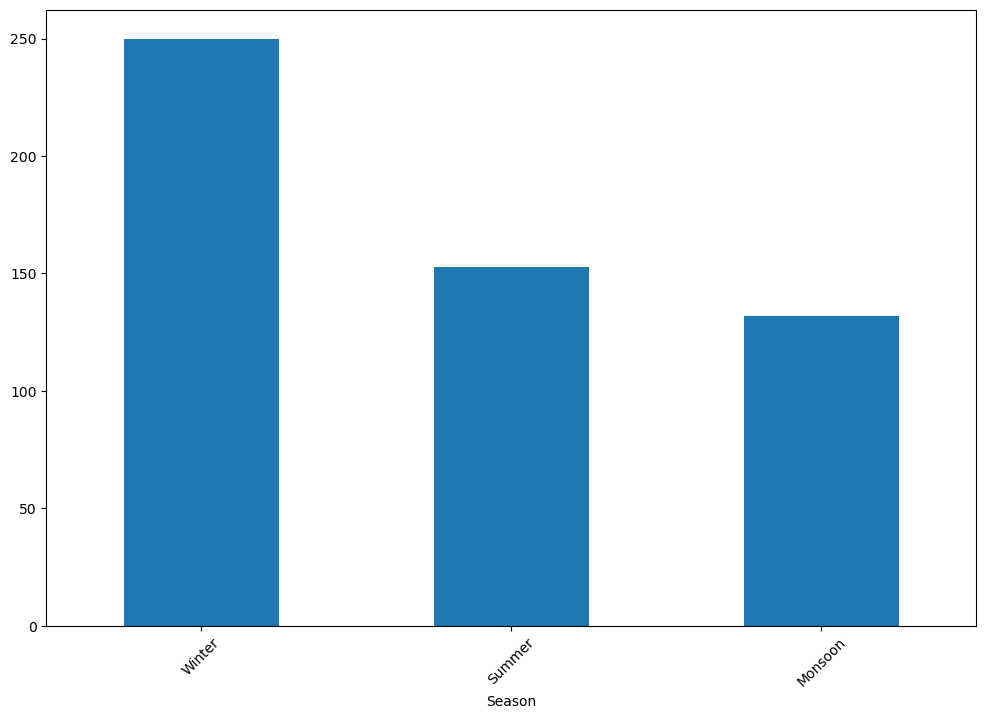

In [31]:
season_aqi = df2.groupby('Season')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
season_aqi.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

### Observation
This plot shows winter has the highest average AQI and monsoon has the lowest. So air quality looks worse in winter in this dataset too.


### Hypothesis Testing
We can test whether the AQI difference across seasons is real, or if it may just be random.


In [32]:
from scipy.stats import kruskal

season_groups = [group['AQI'].dropna() for _, group in df2.groupby('Season') if group['AQI'].dropna().shape[0] > 0]
stat, p_value = kruskal(*season_groups)
print('Kruskal-Wallis statistic:', stat)
print('p-value:', p_value)

if p_value < 0.05:
    print('Conclusion: AQI changes by season in a meaningful way.')
else:
    print('Conclusion: The season difference may be due to random variation.')

Kruskal-Wallis statistic: 14383.362933897351
p-value: 0.0
Conclusion: AQI changes by season in a meaningful way.


### Observation
If the p-value is below 0.05, we can say the seasonal AQI pattern is real in this data. Kruskal-Wallis is a better fit here because AQI is skewed.


## Final Conclusion
This notebook now follows a fuller station-day analysis, not just the missing-value check.

`Xylene` was dropped because too many values were missing.

The station-day data has more rows than the city-day data, so it gives a more detailed view of pollution.

Some stations have much worse average AQI than others, and the data is not equally spread across all stations.

Winter shows the highest average AQI, while monsoon looks cleaner in this station-level data too.

The hypothesis test is added for season because it is a clear and useful comparison in this notebook.
